# PathwayAE — Pathway Visualisations

This notebook analyses the KEGG and Hallmark pathway datasets as well as the TCGA and METABRIC datasets.

## Sources

- KEGG pathway definitions: `c2.cp.kegg.v7.5.1.json`
- Hallmark pathway definitions: `h.all.v7.5.1.json`

Both files are expected in `~/data/pathways/`.

The pathway files currently used in the reproduction are from the current MSigDB release but were renamed to match the filenames expected by the original repository. See the main reproduction notebook for the full source/download notes.

## 1. Imports

In [2]:
import os
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathwayae.utils import from_log2pk, to_log2pk

## 2. Paths

In [3]:
data_folder = os.path.expanduser("~/data/")

pathway_folder = os.path.join(data_folder, "pathways")
tcga_folder = os.path.join(data_folder, "pathwayae", "tcga")
metabric_folder = os.path.join(data_folder, "metabric")

kegg_path = os.path.join(pathway_folder, "c2.cp.kegg.v7.5.1.json")
hallmark_path = os.path.join(pathway_folder, "h.all.v7.5.1.json")

## 3. Load pathway definitions

In [4]:
def load_pathways(path):
    with open(path, "r") as f:
        pathway_data = json.load(f)

    pathway_names = list(pathway_data.keys())
    pathway_genes = [pathway_data[name]["geneSymbols"] for name in pathway_names]

    return pathway_names, pathway_genes


kegg_names, kegg_pathways = load_pathways(kegg_path)
hallmark_names, hallmark_pathways = load_pathways(hallmark_path)

print("KEGG pathways:", len(kegg_pathways))
print("Hallmark pathways:", len(hallmark_pathways))

KEGG pathways: 186
Hallmark pathways: 50


## 4. Load and preprocess gene expression data 

The TCGA and METABRIC gene-expression datasets are loaded and preprocessed using the same gene level preprocessing used in the reproduce PAAE notebook.

In [5]:
### LOAD METABRIC ### 
metabric_gex_path = os.path.join(metabric_folder, "data_mrna_illumina_microarray.txt")

#read the file into pandas dataframe - gex_meta becomes the METABRIC gene-expression table
#hugo_symbol col contains gene identifiers which is why METABRIC doesnt need the Ensembl mapping
gex_meta = pd.read_csv(
    metabric_gex_path, sep="\t", index_col="Hugo_Symbol"
).drop(columns="Entrez_Gene_Id")

gex_meta.index.rename("SampleID", inplace=True)

gex_meta = gex_meta.T.dropna(axis="columns")#transpose the table

gex_meta.columns = gex_meta.columns.str.upper()

print("METABRIC gene expression shape:", gex_meta.shape)

### LOAD TCGA ###
cancer_type = "BRCA"

tcga_gex_path = os.path.join(
    tcga_folder,
    f"TCGA-{cancer_type}.htseq_fpkm.tsv"
)

gex = pd.read_csv(
    tcga_gex_path,
    sep="\t",
    index_col="Ensembl_ID"
).T.dropna(axis="columns")

gex.columns = gex.columns.str.split(".").str[0]

print("Initial TCGA gene expression shape:", gex.shape)

### REMOVE ZERO VARIANCE TCGA genes ###
zero_variance_columns = set(
    gex.var()[gex.var() == 0].index
)

gex = gex.drop(
    columns=list(zero_variance_columns)
)

print("TCGA shape after removing zero-variance genes:", gex.shape)

### Load the ensembl gene symbol mapping ###
ensembl_mapping_path = os.path.join(
    tcga_folder,
    "ensembl_to_gene_id.json"
)

with open(ensembl_mapping_path) as f:
    ensembl_to_gex_dict = json.load(f)

# Strip version suffixes so keys line up with the already-stripped gex.columns
ensembl_to_gex_dict = {k.split(".")[0]: v for k, v in ensembl_to_gex_dict.items()}

### Remove Ensembl IDs that have no gene-name mapping ###
columns_to_drop = [
    k
    for k in ensembl_to_gex_dict
    if ensembl_to_gex_dict[k] == ""
    and k not in zero_variance_columns
]

gex = gex.drop(columns=columns_to_drop, errors="ignore")

### deal with duplicate gene mappings ###
# #if more than one ensembl ID maps to the same gene symbol we dont want multiple of that gene  
value_counts = {}

for k, v in ensembl_to_gex_dict.items():
    if v == '':
        continue
    elif k in gex.columns:
        if v in value_counts:
            value_counts[v].append(k)
        else:
            value_counts[v] = [k]

value_counts = {
    k: v
    for k, v in value_counts.items()
    if len(v) > 1
}

print(
    "Gene symbols with multiple Ensembl IDs:",
    len(value_counts)
)

### Merge duplicate genes ### 
for g_name, g_ensembl_ids in value_counts.items():
    gex[g_name] = to_log2pk(
        from_log2pk(
            gex[g_ensembl_ids],
            1
        ).mean(axis=1),
        1
    )

    gex.drop(
        columns=g_ensembl_ids,
        inplace=True
    )

### Rename the reamining TCGA genes ###
gex = gex.rename(
    columns=ensembl_to_gex_dict
)

gex.columns.rename(
    "GeneName",
    inplace=True
)

gex.index.rename(
    "SampleID",
    inplace=True
)

print("Processed TCGA shape:", gex.shape)

n_unmapped = sum(1 for c in gex.columns if str(c).startswith("ENSG"))
print(f"TCGA columns still raw Ensembl IDs: {n_unmapped} / {gex.shape[1]}")


METABRIC gene expression shape: (1980, 20592)
Initial TCGA gene expression shape: (1226, 60660)
TCGA shape after removing zero-variance genes: (1226, 58004)
Gene symbols with multiple Ensembl IDs: 105


C:\Users\micha\AppData\Local\Temp\ipykernel_25792\418338993.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gex[g_name] = to_log2pk(
C:\Users\micha\AppData\Local\Temp\ipykernel_25792\418338993.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gex[g_name] = to_log2pk(
C:\Users\micha\AppData\Local\Temp\ipykernel_25792\418338993.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

Processed TCGA shape: (1226, 56671)
TCGA columns still raw Ensembl IDs: 3613 / 56671


## 5. Number of genes 
##### The number of genes in both the TCGA and METABRIC datasets.

In [6]:
all_tcga_genes = set(gex.columns)
all_metabric_genes = set(gex_meta.columns)

print(f"TCGA total genes: {len(all_tcga_genes)}")
print(f"METABRIC total genes: {len(all_metabric_genes)}\n")

TCGA total genes: 56671
METABRIC total genes: 20374



## 6. Gene coverage
##### Calculates the overlap between the union of gene and pathway sets. 

In [7]:

#takes the genes currently in the 2 datasets and turns them into sets, sets enforce uniqueness  
tcga_genes_full = set(gex.columns)
metabric_genes_full = set(gex_meta.columns)
combined_dataset_genes = tcga_genes_full | metabric_genes_full

#takes the 2d structure and turns it into a 1d set again the set enforces uniqueness 
kegg_genes = set(g for pathway in kegg_pathways for g in pathway)
hallmark_genes = set(g for pathway in hallmark_pathways for g in pathway)
combined_pathway_genes = kegg_genes | hallmark_genes #or

def coverage(dataset_name, dataset_genes, pathway_name, pathway_genes):
    n_covered = len(dataset_genes & pathway_genes)#finds the overlap the genes that are in the geneset and also in the pathway set
    pct = 100 * n_covered / len(dataset_genes)
    print(f"{dataset_name} genes covered by {pathway_name}: "
          f"{n_covered} / {len(dataset_genes)} ({pct:.2f}%)")

print(f"TCGA total genes: {len(tcga_genes_full)}")
print(f"METABRIC total genes: {len(metabric_genes_full)}\n")

coverage("TCGA", tcga_genes_full, "KEGG", kegg_genes)
coverage("TCGA", tcga_genes_full, "Hallmark", hallmark_genes)
coverage("TCGA", tcga_genes_full, "KEGG+Hallmark combined", combined_pathway_genes)
print()
coverage("METABRIC", metabric_genes_full, "KEGG", kegg_genes)
coverage("METABRIC", metabric_genes_full, "Hallmark", hallmark_genes)
coverage("METABRIC", metabric_genes_full, "KEGG+Hallmark combined", combined_pathway_genes)

#the genes in tcga or metabric that are also in kegg or hallmark 
covered_genes = combined_dataset_genes & combined_pathway_genes
percentage = 100 * (len(covered_genes)/len(combined_dataset_genes))
print(
    f"\n\n TCGA + METABRIC genes covered by KEGG+Hallmark combined: "
    f"{len(covered_genes)} / {len(combined_dataset_genes)} ({percentage:.2f}%)"
)


TCGA total genes: 56671
METABRIC total genes: 20374

TCGA genes covered by KEGG: 5079 / 56671 (8.96%)
TCGA genes covered by Hallmark: 4313 / 56671 (7.61%)
TCGA genes covered by KEGG+Hallmark combined: 7132 / 56671 (12.58%)

METABRIC genes covered by KEGG: 5127 / 20374 (25.16%)
METABRIC genes covered by Hallmark: 4326 / 20374 (21.23%)
METABRIC genes covered by KEGG+Hallmark combined: 7183 / 20374 (35.26%)


 TCGA + METABRIC genes covered by KEGG+Hallmark combined: 7279 / 58358 (12.47%)


## 7. Gene coverage 
##### Calcuates the overlap between the intersection of gene and pathway sets.

In [8]:
### Find genes shared by TCGA and METABRIC ### 
genes_in_both = sorted(set(gex_meta.columns).intersection(set(gex.columns)))

print("Number of genes shared by TCGA and METABRIC:", len(genes_in_both))

shared_genes = set(genes_in_both)

def coverage(pathway_name, pathway_genes):
    n_covered = len(shared_genes & pathway_genes)
    pct = 100 * n_covered / len(shared_genes)
    print(f"Shared TCGA/METABRIC genes covered by {pathway_name}: "
          f"{n_covered} / {len(shared_genes)} ({pct:.2f}%)")

coverage("KEGG", kegg_genes)
coverage("Hallmark", hallmark_genes)
coverage("KEGG+Hallmark combined", kegg_genes | hallmark_genes)

### Restrict both datasets to those shared genes ###
gex = gex.loc[:, genes_in_both]
gex_meta = gex_meta.loc[:, genes_in_both]

print("Final TCGA shape:", gex.shape)
print("Final METABRIC shape:", gex_meta.shape) 


kegg_genes = set(
    gene
    for pathway in kegg_pathways
    for gene in pathway
)

hallmark_genes = set(
    gene
    for pathway in hallmark_pathways
    for gene in pathway
)

tcga_genes = set(gex.columns)
metabric_genes = set(gex_meta.columns)

tcga_kegg = tcga_genes.intersection(kegg_genes)
tcga_hallmark = tcga_genes.intersection(hallmark_genes)

metabric_kegg = metabric_genes.intersection(kegg_genes)
metabric_hallmark = metabric_genes.intersection(hallmark_genes)

tcga_kegg_percentage = len(tcga_kegg) / len(tcga_genes) * 100
tcga_hallmark_percentage = len(tcga_hallmark) / len(tcga_genes) * 100

metabric_kegg_percentage = len(metabric_kegg) / len(metabric_genes) * 100
metabric_hallmark_percentage = len(metabric_hallmark) / len(metabric_genes) * 100

print(f"TCGA genes covered by KEGG: {len(tcga_kegg)} / {len(tcga_genes)} ({tcga_kegg_percentage:.2f}%)")
print(f"TCGA genes covered by Hallmark: {len(tcga_hallmark)} / {len(tcga_genes)} ({tcga_hallmark_percentage:.2f}%)")
print(f"METABRIC genes covered by KEGG: {len(metabric_kegg)} / {len(metabric_genes)} ({metabric_kegg_percentage:.2f}%)")
print(f"METABRIC genes covered by Hallmark: {len(metabric_hallmark)} / {len(metabric_genes)} ({metabric_hallmark_percentage:.2f}%)")

Number of genes shared by TCGA and METABRIC: 18687
Shared TCGA/METABRIC genes covered by KEGG: 5005 / 18687 (26.78%)
Shared TCGA/METABRIC genes covered by Hallmark: 4277 / 18687 (22.89%)
Shared TCGA/METABRIC genes covered by KEGG+Hallmark combined: 7036 / 18687 (37.65%)
Final TCGA shape: (1226, 18687)
Final METABRIC shape: (1980, 18885)
TCGA genes covered by KEGG: 5005 / 18687 (26.78%)
TCGA genes covered by Hallmark: 4277 / 18687 (22.89%)
METABRIC genes covered by KEGG: 5005 / 18687 (26.78%)
METABRIC genes covered by Hallmark: 4277 / 18687 (22.89%)


## 8. minimum, maximum and mean number of genes in a pathway

In [9]:
def pathway_size_statistics(pathways):
    sizes = np.array([len(genes) for genes in pathways])

    print(f"Minimum number of genes: {sizes.min()}")
    print(f"Maximum number of genes: {sizes.max()}")
    print(f"Mean number of genes: {sizes.mean()}")

    return sizes


print("KEGG")
kegg_pathway_sizes = pathway_size_statistics(kegg_pathways)

print("\nHallmark")
hallmark_pathway_sizes = pathway_size_statistics(hallmark_pathways)

KEGG
Minimum number of genes: 10
Maximum number of genes: 389
Mean number of genes: 68.8225806451613

Hallmark
Minimum number of genes: 32
Maximum number of genes: 200
Mean number of genes: 146.44


## 9. Gene recurrence across pathways

Tells us the number of unique genes in the pathway definitions, the most common gene in the pathway defintions, and the gene that occurs in the largest number of pathways.

In [10]:
kegg_gene_counts = Counter(
    gene
    for pathway in kegg_pathways
    for gene in set(pathway)
)

hallmark_gene_counts = Counter(
    gene
    for pathway in hallmark_pathways
    for gene in set(pathway)
)

print("KEGG Number of unique genes:", len(kegg_gene_counts))
print("Most recurring KEGG gene:", kegg_gene_counts.most_common(1)[0])
print("Maximum pathway recurrence:", max(kegg_gene_counts.values()))

print()

print("Hallmark Number of unique genes:", len(hallmark_gene_counts))
print("Most recurring Hallmark gene:", hallmark_gene_counts.most_common(1)[0])
print("Maximum pathway recurrence:", max(hallmark_gene_counts.values()))
#the gene that occurs in the largest number of pathways occurs in num pathwayss

KEGG Number of unique genes: 5246
Most recurring KEGG gene: ('MAPK1', 46)
Maximum pathway recurrence: 46

Hallmark Number of unique genes: 4384
Most recurring Hallmark gene: ('MYC', 10)
Maximum pathway recurrence: 10


## 10. The number of genes covered/not covered by pathways 

In [11]:
# Genes not covered by KEGG or Hallmark

tcga_not_covered = tcga_genes_full - combined_pathway_genes
metabric_not_covered = metabric_genes_full - combined_pathway_genes

print(
    f"TCGA genes not covered by KEGG+Hallmark: "
    f"{len(tcga_not_covered)} / {len(tcga_genes_full)} "
    f"({100 * len(tcga_not_covered) / len(tcga_genes_full):.2f}%)"
)

print(
    f"METABRIC genes not covered by KEGG+Hallmark: "
    f"{len(metabric_not_covered)} / {len(metabric_genes_full)} "
    f"({100 * len(metabric_not_covered) / len(metabric_genes_full):.2f}%)"
)

TCGA genes not covered by KEGG+Hallmark: 49539 / 56671 (87.42%)
METABRIC genes not covered by KEGG+Hallmark: 13191 / 20374 (64.74%)


## 11. Most recurring genes

In [12]:
top_kegg_genes = pd.DataFrame(
    kegg_gene_counts.most_common(20),
    columns=["Gene", "Number_of_Pathways"]
)

top_hallmark_genes = pd.DataFrame(
    hallmark_gene_counts.most_common(20),
    columns=["Gene", "Number_of_Pathways"]
)

print("Top 20 KEGG genes:")
display(top_kegg_genes)

print("Top 20 Hallmark genes:")
display(top_hallmark_genes)

Top 20 KEGG genes:


,Gene,Number_of_Pathways
0,MAPK1,46
1,MAPK3,46
2,MAP2K1,37
3,KRAS,34
4,PIK3CA,34
5,PIK3CD,34
6,PIK3CB,34
7,PIK3CG,34
8,PIK3R2,33
9,PIK3R5,33


Top 20 Hallmark genes:


,Gene,Number_of_Pathways
0,MYC,10
1,CDKN1A,10
2,IL6,10
3,SERPINE1,9
4,BTG2,8
5,CD44,8
6,PLAUR,8
7,IRF1,8
8,RETSAT,8
9,IDH1,8


## 12. Histogram: number of pathways per gene

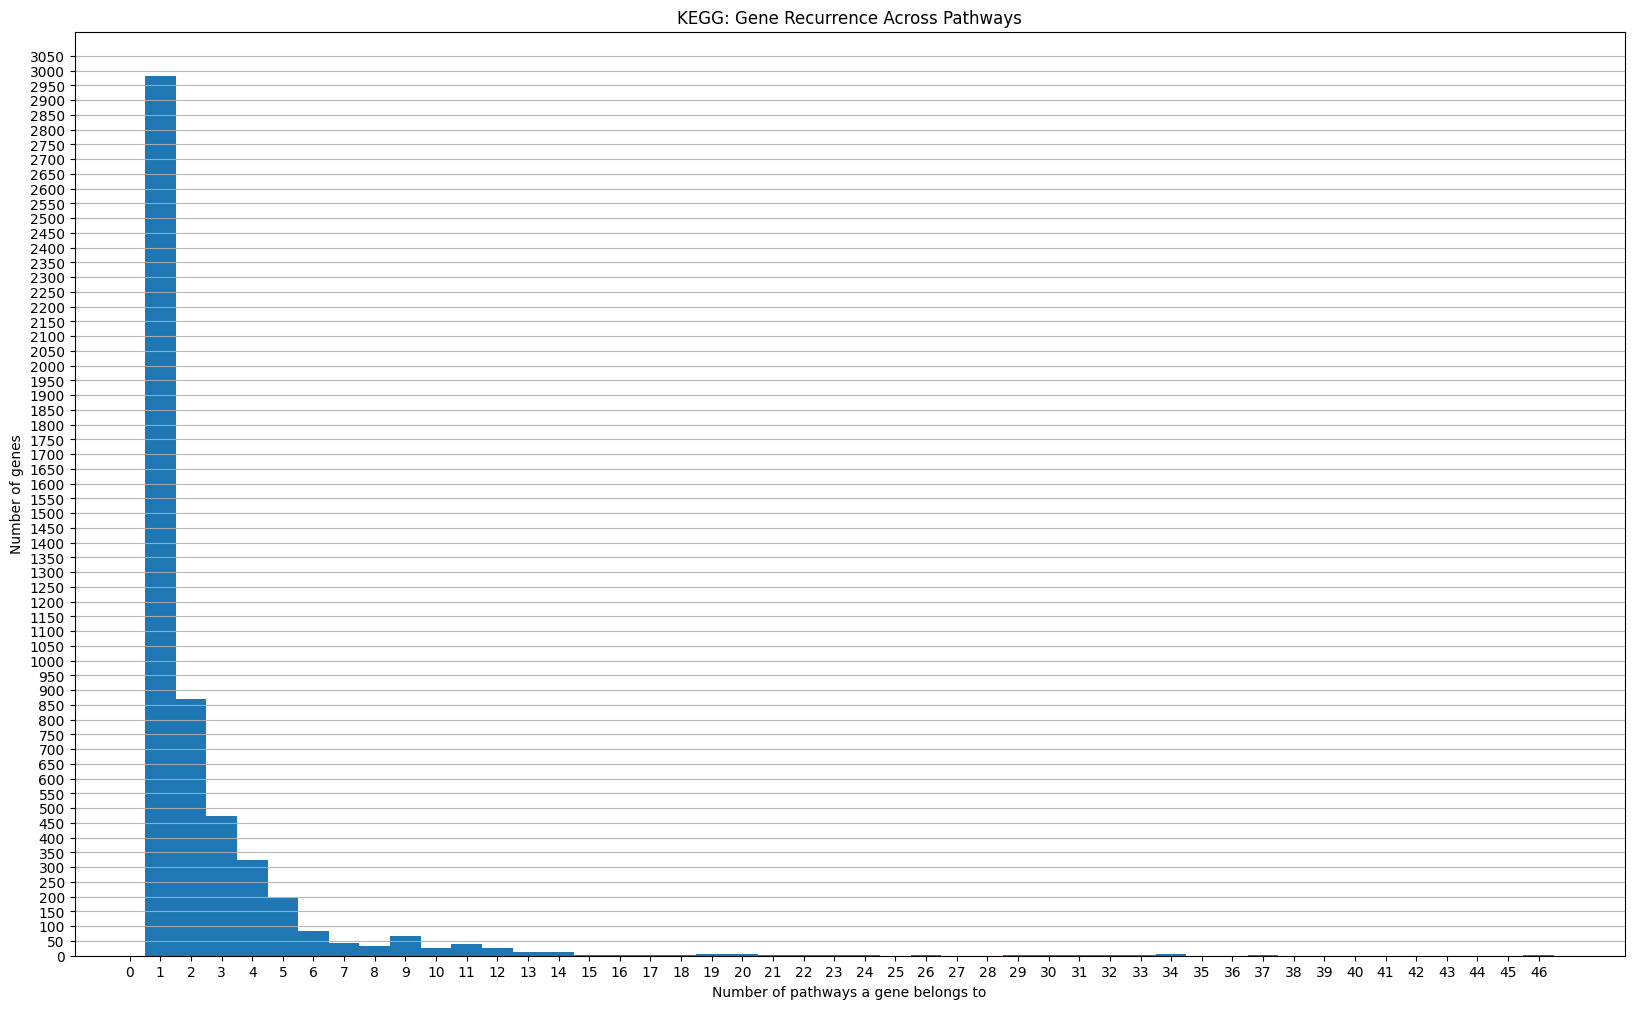

In [13]:
plt.figure(figsize=(20, 12))

plt.hist(
    list(kegg_gene_counts.values()),
    bins=np.arange(0.5, max(kegg_gene_counts.values()) + 1.5, 1),
)

plt.xlabel("Number of pathways a gene belongs to")
plt.ylabel("Number of genes")
plt.title("KEGG: Gene Recurrence Across Pathways")
plt.xticks(range(0, max(kegg_gene_counts.values()) + 1))
plt.yticks(range(0, 3100, 50))

plt.grid(axis="y", alpha=0.9)
plt.show()

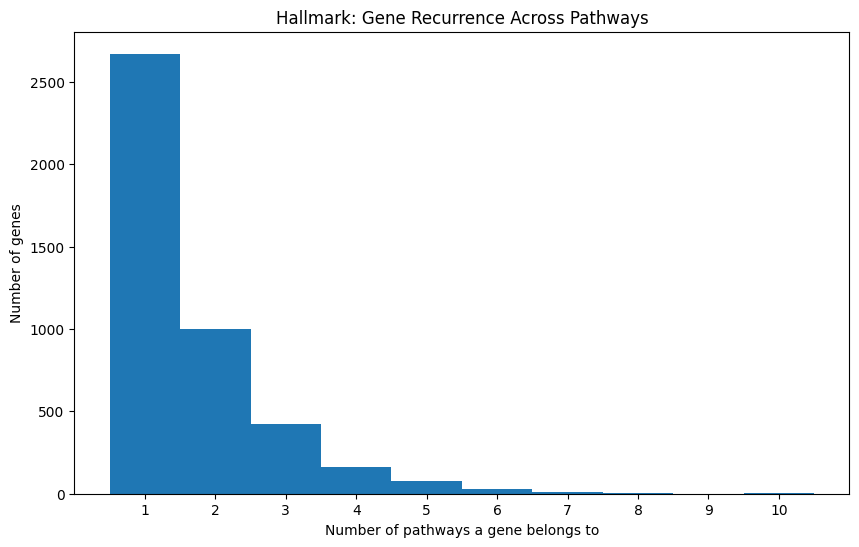

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    list(hallmark_gene_counts.values()),
    bins=np.arange(0.5, max(hallmark_gene_counts.values()) + 1.5, 1),
)

plt.xlabel("Number of pathways a gene belongs to")
plt.ylabel("Number of genes")
plt.title("Hallmark: Gene Recurrence Across Pathways")
plt.xticks(range(1, max(hallmark_gene_counts.values()) + 1))
plt.show()

## 13. Pathway overlap heatmaps

Each cell shows the **number of genes shared by a pair of pathways**. The diagonal is each pathway compared with itself, so it corresponds to the pathway's size.

The axes use pathway indices, there are 186 KEGG pathways and 50 Hallmark pathways.

In [15]:
def pathway_overlap_matrix(pathways):
    pathway_sets = [set(genes) for genes in pathways]
    n = len(pathway_sets)

    overlap = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(i, n):
            shared = len(pathway_sets[i].intersection(pathway_sets[j]))
            overlap[i, j] = shared
            overlap[j, i] = shared

    return overlap


kegg_overlap = pathway_overlap_matrix(kegg_pathways)
hallmark_overlap = pathway_overlap_matrix(hallmark_pathways)

print("KEGG overlap matrix:", kegg_overlap.shape)
print("Hallmark overlap matrix:", hallmark_overlap.shape)

KEGG overlap matrix: (186, 186)
Hallmark overlap matrix: (50, 50)


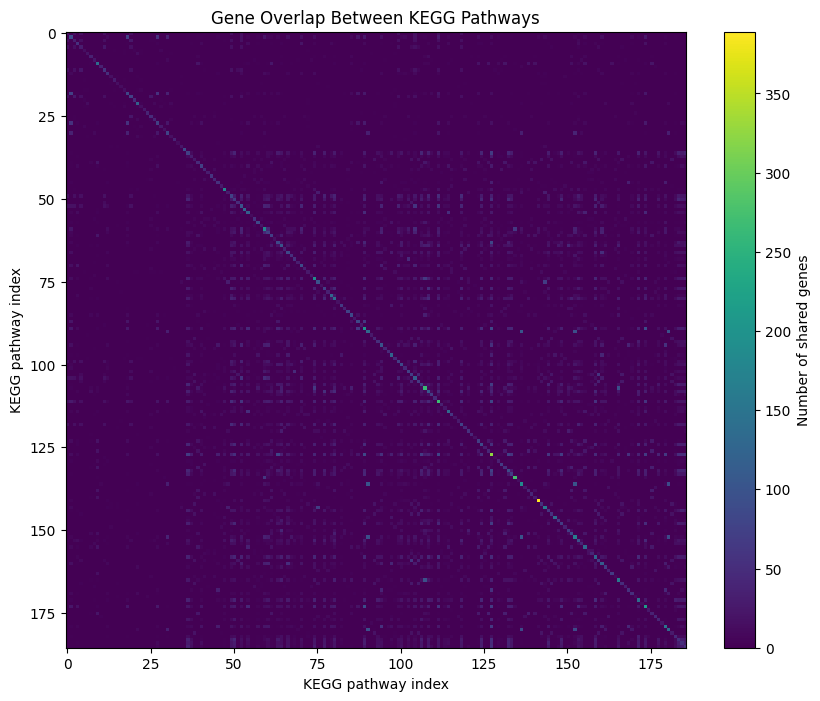

In [16]:
plt.figure(figsize=(10, 8))

plt.imshow(kegg_overlap, aspect="auto")
plt.colorbar(label="Number of shared genes")
plt.xlabel("KEGG pathway index")
plt.ylabel("KEGG pathway index")
plt.title("Gene Overlap Between KEGG Pathways")
plt.show()

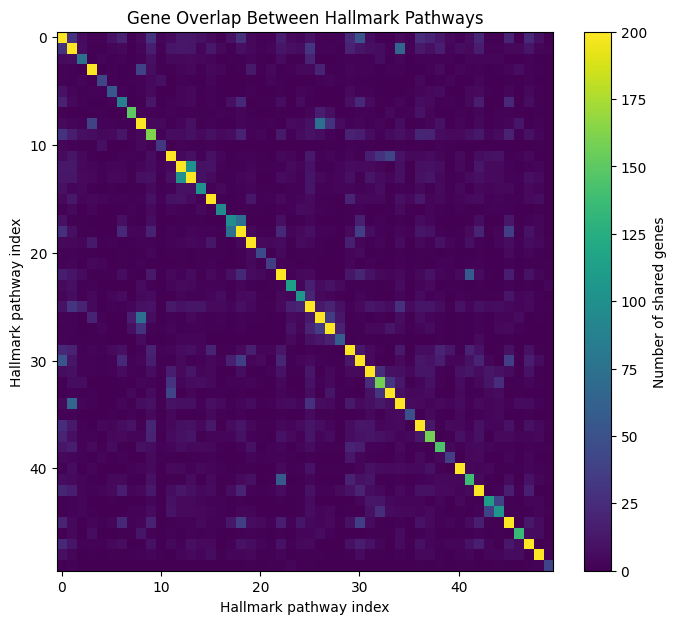

In [17]:
plt.figure(figsize=(8, 7))

plt.imshow(hallmark_overlap, aspect="auto")
plt.colorbar(label="Number of shared genes")
plt.xlabel("Hallmark pathway index")
plt.ylabel("Hallmark pathway index")
plt.title("Gene Overlap Between Hallmark Pathways")
plt.show()